In [1]:
import pandas as pd
import numpy as np
import pandas_ta as ta
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import joblib

In [2]:
df = pd.read_csv('AUDUSD_M15_20241030.csv', parse_dates=["Date"], index_col=0)

In [3]:
# target calculation
df['returns'] = df['Close'].pct_change()
df['target'] = (df['returns'] > 0).astype(int)
df['s_returns'] = df['returns']
df['cumulative_buy_and_hold_returns'] = df["returns"].cumsum().apply(np.exp)

# Shift price and returns to prevent lookahead bias
df['Close'] = df['Close'].shift(1)
df['Open'] = df['Open'].shift(1)
df['High'] = df['High'].shift(1)
df['Low'] = df['Low'].shift(1)
df['returns'] = df['returns'].shift(1)
df['volatility'] = df['returns'].rolling(window=8).std()
df['returns_div_volatility'] = df['returns'] / df['volatility'].replace(0, np.nan)
df['returns_inv'] = 1 / df['returns'].replace(0, np.nan)
df['volatility_inv'] = 1 / df['volatility'].replace(0, np.nan)
# df[['stoch_k', 'stoch_d']] = ta.stoch(df['High'], df['Low'], df['Close'], 13, 3, 3)
# df['stoch'] = np.where(
#     (df['stoch_k'] > df['stoch_d']) & (df['stoch_k'] <= 20), 1,
#     np.where((df['stoch_k'] < df['stoch_d']) & (df['stoch_k'] >= 80), -1, 0)
# )

df[["lower", "mid","upper","bandwidth","percent"]] = ta.bbands(df["Close"], length=21, std=2)
df['distance'] = df['Close'] - df['mid']
df["position"] = np.where(df.Close < df.lower, 1, np.nan) # 1. oversold -> go long
df["position"] = np.where(df.Close > df.upper, -1, df["position"]) # 2. overbought -> go short
df["position"] = np.where(df.distance * df.distance.shift(1) < 0, 0, df["position"]) # 3. crossing SMA ("Middle Band") -> go neutral
df["position"] = df.position.ffill().fillna(0)
df.dropna(inplace=True)

#HMM
feature_matrix = df[['returns', 'volatility']]
scaler_hmm = StandardScaler()
feature_matrix_scaled = scaler_hmm.fit_transform(feature_matrix)
hmm_model = GaussianHMM(n_components = 5, covariance_type="full", n_iter = 100 , random_state=42)
hmm_model.fit(feature_matrix_scaled)
df['hmm_regime'] = hmm_model.predict(feature_matrix_scaled)
probabilities = hmm_model.predict_proba(feature_matrix_scaled)
df['hmm_prob_0'] = probabilities[:, 0]
df['hmm_prob_1'] = probabilities[:, 1]
df['hmm_prob_2'] = probabilities[:, 2]
df['hmm_prob_3'] = probabilities[:, 3]
df['hmm_prob_4'] = probabilities[:, 4]

# Final clean up
df.replace([np.inf, -np.inf], 0, inplace=True)
df.dropna(inplace=True)

In [4]:
# features
features = df.drop(columns=['target', 's_returns', 'cumulative_buy_and_hold_returns', 'Close', 'Open', 'High', 'Low',"lower", "mid","upper","bandwidth","percent",'distance', 'position']).columns

# Define features and target
X = df[features]
y = df["target"]

# Apply StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Convert the scaled NumPy array back to a DataFrame
X = pd.DataFrame(X, columns=features)

In [5]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_clf = RandomForestClassifier(n_estimators=500,
                                max_depth=5,
                                class_weight = 'balanced',
                                random_state=42)

model = rf_clf

# Train the model on the training set
model.fit(X_train, y_train)

# Predict and calculate accuracy for training and testing sets
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

accuracy_train = accuracy_score(y_train, y_pred_train) * 100
accuracy_test = accuracy_score(y_test, y_pred_test) * 100

# Print train and test accuracy
print(f"Train Accuracy: {accuracy_train:.2f}")
print(f"Test Accuracy: {accuracy_test:.2f}")

# Predict on the entire dataset
df['pred'] = model.predict(X)
total_accuracy = accuracy_score(df.target, df.pred) * 100
print(f"Total Accuracy: {total_accuracy:.2f}")

# Get predicted probabilities for each class
probs = model.predict_proba(X)

# Add these probabilities to the dataframe
df['prob_class_-1'] = probs[:, 0]
df['prob_class_1'] = probs[:, 1]
df['prob'] = np.where(df['prob_class_1'] > df['prob_class_-1'], df['prob_class_1'], df['prob_class_-1'])

Train Accuracy: 54.25
Test Accuracy: 53.57
Total Accuracy: 54.12


In [6]:
A_wlr_th = 0.977
A_raw_accuracy_th = 53.5
A_filtered_accuracy_th = 54.5
A_sharp_ratio_th = 9
A_max_dd_th = 0.04
A_position_count_th = 22244
A_cumulative_th = 2.75
A_annual_th = 1.16

In [7]:
objects_to_save = {
    'clf': model,
    'hmm': hmm_model,
    'scaler': scaler,
    'scaler_hmm': scaler_hmm,
    'wlr': A_wlr_th,
    'raw_accuracy': A_raw_accuracy_th,
    'filtered_accuracy': A_filtered_accuracy_th,
    'sharp_ratio': A_sharp_ratio_th,
    'max_dd': A_max_dd_th,
    'position_count': A_position_count_th,
    'cumulative': A_cumulative_th,
    'annual' : A_annual_th}
joblib.dump(objects_to_save, 'U_A.joblib')

['U_A.joblib']

# Filter and Evaluations

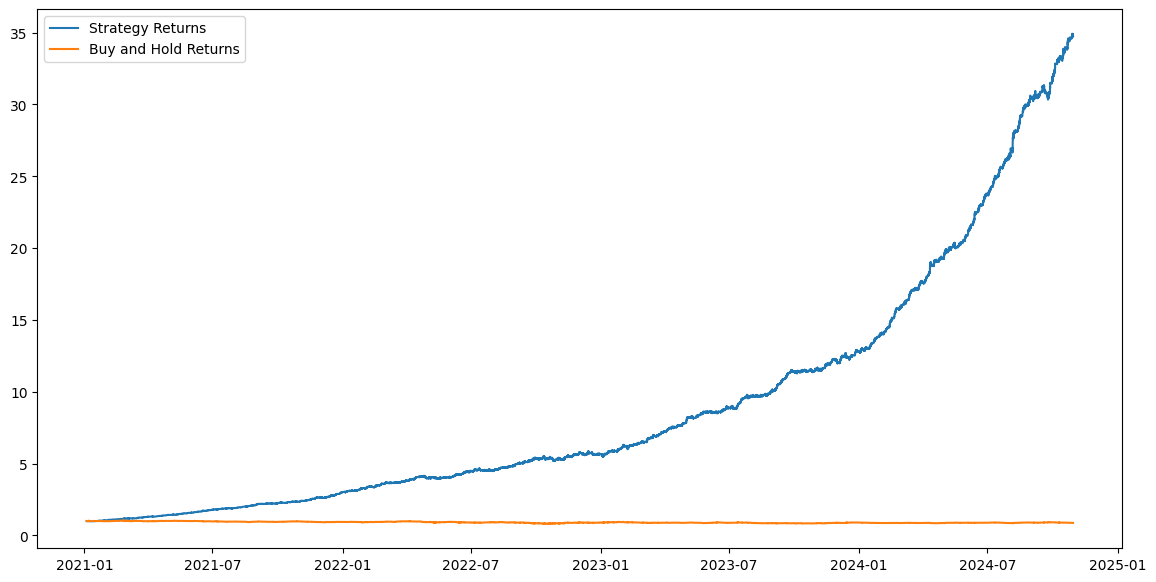

In [45]:
# strategy
df['pred'] = df['pred'].map({0: -1, 1: 1})
df['strategy'] = df['pred'] * df['s_returns']
df['cumulative_strategy_returns'] = df["strategy"].cumsum().apply(np.exp)

# plot
plt.figure(figsize=(14,7))
plt.plot(df['cumulative_strategy_returns'], label=f'Strategy Returns')
plt.plot(df['cumulative_buy_and_hold_returns'], label=f'Buy and Hold Returns')
plt.legend()
plt.show()

In [46]:
# Actual returns associated with each trade
annualized_factor = 24960  # The number of 15-minute bars in a year
annualized_sreturn = np.mean(df['strategy']) * annualized_factor
print(f"Annualized Strategy Return: {annualized_sreturn:.2f}")

# Sharpe Ratio
risk_free_rate = 0  # Assuming risk-free rate is 0 for simplicity
mean_return = np.mean(df['strategy']) * annualized_factor
std_return = np.std(df['strategy']) * np.sqrt(annualized_factor)
sharpe_ratio = (mean_return - risk_free_rate) / std_return
print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f}")


# Maximum Drawdown
def max_drawdown(strategy_returns):
    cumulative = np.cumsum(strategy_returns)
    drawdown = cumulative - np.maximum.accumulate(cumulative)
    return np.min(drawdown)

max_dd = max_drawdown(df['strategy'])
print(f"Maximum Drawdown: {max_dd:.2f}")

Annualized Strategy Return: 0.96
Annualized Sharpe Ratio: 8.67
Maximum Drawdown: -0.07


In [47]:
print(df.target.value_counts())
print(df.pred.value_counts())
print(df.position.value_counts())

target
0    46342
1    45655
Name: count, dtype: int64
pred
 1    50608
-1    41389
Name: count, dtype: int64
position
 0.0    41681
 1.0    25503
-1.0    24813
Name: count, dtype: int64


In [48]:
# Calculate wins and losses, treating losses as positive values
df['loss'] = np.where(df['strategy'] < 0, abs(df['strategy']), np.nan)
df['win'] = np.where(df['strategy'] > 0, df['strategy'], np.nan)

# Calculate the average win-to-loss ratio
win_loss_ratio = df['win'].mean() / df['loss'].mean()

# Handle cases where loss is zero or NaN
win_loss_ratio = np.where(np.isnan(win_loss_ratio) | (win_loss_ratio == 0), 1, win_loss_ratio)

# Calculate the Kelly Criterion using the improved formula
df['kelly'] = (df['prob'] - (1 - df['prob']) / win_loss_ratio)
win_loss_ratio

array(0.99008887)

In [49]:
df.describe()

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,hmm_prob_4,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
count,91997.000000,91997.000000,91997.000000,91997.000000,91997.000000,91997.000000,91997.000000,91997.000000,91997.000000,91997.000000,...,91997.000000,91997.000000,91997.000000,91997.000000,91997.000000,91997.000000,91997.000000,41477.000000,49306.000000,91997.000000
mean,0.694830,0.695155,0.694502,0.694830,-0.000002,0.496266,-0.000001,0.913182,0.000596,0.001044,...,0.336485,0.100210,0.500115,0.499885,0.521845,0.000039,8.839544,0.000483,0.000479,0.038903
std,0.042403,0.042405,0.042398,0.042403,0.000707,0.499989,0.000704,0.049689,0.000378,1.029995,...,0.433461,0.994972,0.037632,0.037632,0.030642,0.000703,8.284874,0.000531,0.000512,0.061591
min,0.617940,0.619770,0.616960,0.617920,-0.016662,0.000000,-0.016662,0.811601,0.000041,-4.161356,...,0.000000,-1.000000,0.274182,0.214571,0.500000,-0.016662,0.983082,0.000013,0.000013,-0.005005
25%,0.661640,0.661900,0.661340,0.661630,-0.000337,0.000000,-0.000332,0.876480,0.000361,-0.693246,...,0.000006,-1.000000,0.488023,0.491819,0.506455,-0.000287,2.763792,0.000150,0.000163,0.007969
50%,0.680260,0.680600,0.679870,0.680250,0.000014,0.000000,0.000000,0.898527,0.000512,0.022486,...,0.006803,1.000000,0.496048,0.503952,0.510751,0.000046,5.580560,0.000333,0.000346,0.016604
75%,0.727190,0.727460,0.726830,0.727180,0.000340,1.000000,0.000335,0.948654,0.000724,0.701060,...,0.917230,1.000000,0.508181,0.511977,0.523480,0.000376,11.652068,0.000642,0.000634,0.042191
max,0.800600,0.800640,0.799850,0.800590,0.019907,1.000000,0.019907,1.041010,0.007029,4.613150,...,0.999745,1.000000,0.785429,0.725818,0.785429,0.019907,34.921704,0.016662,0.019907,0.568711


In [50]:
df_filtered = df[((df['position'] == 1) & (df['pred'] == 1)) | ((df['position'] == -1) & (df['pred'] == -1))].copy()

In [51]:
df_filtered

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,hmm_prob_4,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04 09:45:00,0.77224,0.77298,0.77213,0.77298,0.000919,0,-0.000957,1.003493,0.000400,2.299469,...,0.960499,-1,0.529339,0.470661,0.529339,0.000957,0.996969,NaN,0.000957,0.053967
2021-01-04 10:30:00,0.77205,0.77243,0.77191,0.77227,0.000285,1,0.001282,1.004819,0.000624,0.456462,...,0.399366,-1,0.508085,0.491915,0.508085,-0.001282,0.995731,0.001282,NaN,0.011246
2021-01-04 10:45:00,0.77227,0.77329,0.77217,0.77326,0.001282,1,0.000375,1.005196,0.000707,1.813265,...,0.008627,-1,0.525086,0.474914,0.525086,-0.000375,0.995358,0.000375,NaN,0.045419
2021-01-04 11:00:00,0.77326,0.77357,0.77316,0.77355,0.000375,0,-0.000194,1.005001,0.000703,0.533683,...,0.002355,-1,0.506265,0.493735,0.506265,0.000194,0.995551,NaN,0.000194,0.007588
2021-01-04 11:30:00,0.77340,0.77395,0.77340,0.77367,0.000349,1,0.000026,1.005378,0.000701,0.498288,...,0.045422,-1,0.503193,0.496807,0.503193,-0.000026,0.995873,0.000026,NaN,0.001412
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-29 14:45:00,0.65554,0.65561,0.65532,0.65555,0.000015,1,0.000229,0.871865,0.000299,0.051051,...,0.000044,1,0.459307,0.540693,0.540693,0.000229,34.811267,NaN,0.000229,0.076787
2024-10-29 15:15:00,0.65570,0.65608,0.65555,0.65575,0.000076,0,-0.000351,0.871626,0.000352,0.216637,...,0.003491,1,0.477100,0.522900,0.522900,-0.000351,34.796406,0.000351,NaN,0.041023
2024-10-29 15:30:00,0.65576,0.65586,0.65538,0.65552,-0.000351,0,-0.000854,0.870882,0.000297,-1.181133,...,0.012005,1,0.496118,0.503882,0.503882,-0.000854,34.766692,0.000854,NaN,0.002797


In [52]:
df_filtered['pred'] = df_filtered['pred'].map({-1: 0, 1: 1})
accuracy = accuracy_score(df_filtered.target, df_filtered.pred) * 100
accuracy

53.960631941644365

In [53]:
print(df_filtered.target.value_counts())
print(df_filtered.pred.value_counts())
print(df_filtered.position.value_counts())

target
0    13948
1    13333
Name: count, dtype: int64
pred
1    14929
0    12352
Name: count, dtype: int64
position
 1.0    14929
-1.0    12352
Name: count, dtype: int64


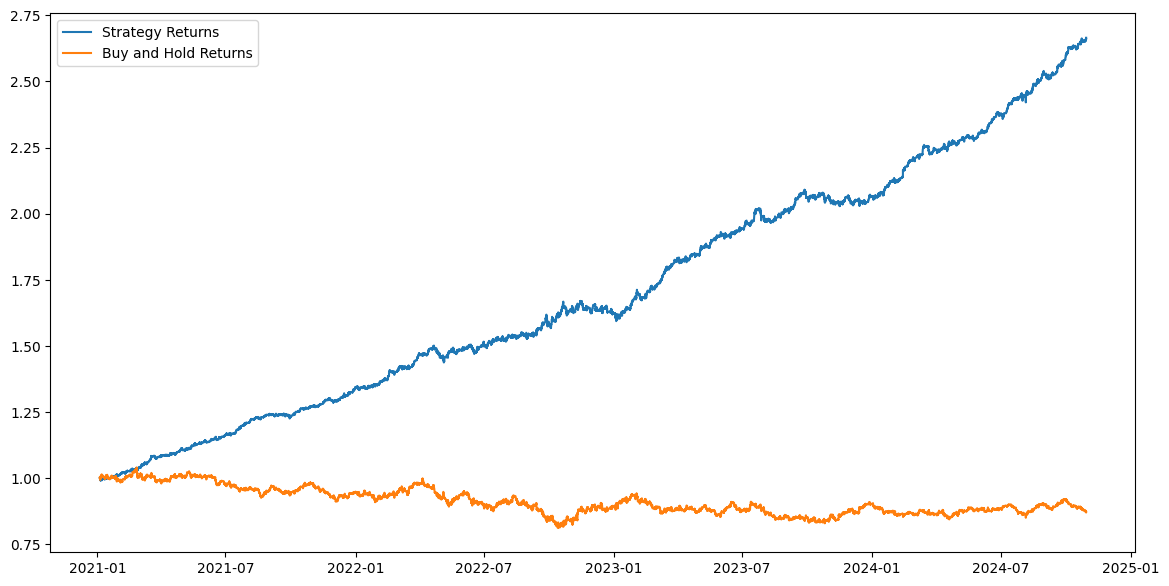

In [54]:
# strategy
df_filtered['pred'] = df_filtered['pred'].map({0: -1, 1: 1})
df_filtered['strategy'] = df_filtered['pred'] * df_filtered['s_returns']
df_filtered['cumulative_strategy_returns'] = df_filtered["strategy"].cumsum().apply(np.exp)

# plot
plt.figure(figsize=(14,7))
plt.plot(df_filtered['cumulative_strategy_returns'], label=f'Strategy Returns')
plt.plot(df_filtered['cumulative_buy_and_hold_returns'], label=f'Buy and Hold Returns')
plt.legend()
plt.show()

In [55]:
# Actual returns associated with each trade
annualized_factor = 24960  # The number of 15-minute bars in a year
annualized_sreturn = np.mean(df_filtered['strategy']) * annualized_factor
print(f"Annualized Strategy Return: {annualized_sreturn:.2f}")

# Sharpe Ratio
risk_free_rate = 0  # Assuming risk-free rate is 0 for simplicity
mean_return = np.mean(df_filtered['strategy']) * annualized_factor
std_return = np.std(df_filtered['strategy']) * np.sqrt(annualized_factor)
sharpe_ratio = (mean_return - risk_free_rate) / std_return
print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f}")


# Maximum Drawdown
def max_drawdown(strategy_returns):
    cumulative = np.cumsum(strategy_returns)
    drawdown = cumulative - np.maximum.accumulate(cumulative)
    return np.min(drawdown)

max_dd = max_drawdown(df_filtered['strategy'])
print(f"Maximum Drawdown: {max_dd:.2f}")

Annualized Strategy Return: 0.90
Annualized Sharpe Ratio: 7.79
Maximum Drawdown: -0.05


In [56]:
# Calculate wins and losses, treating losses as positive values
df_filtered['loss'] = np.where(df_filtered['strategy'] < 0, abs(df_filtered['strategy']), np.nan)
df_filtered['win'] = np.where(df_filtered['strategy'] > 0, df_filtered['strategy'], np.nan)

# Calculate the average win-to-loss ratio
win_loss_ratio = df_filtered['win'].mean() / df_filtered['loss'].mean()

# Handle cases where loss is zero or NaN
win_loss_ratio = np.where(np.isnan(win_loss_ratio) | (win_loss_ratio == 0), 1, win_loss_ratio)

# Calculate the Kelly Criterion using the improved formula
df_filtered['kelly'] = (df_filtered['prob'] - (1 - df_filtered['prob']) / win_loss_ratio)
win_loss_ratio

array(0.97957004)

In [57]:
df_filtered.describe()

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,hmm_prob_4,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
count,27281.000000,27281.000000,27281.000000,27281.000000,27281.000000,27281.000000,27281.000000,27281.000000,27281.000000,27281.000000,...,27281.000000,27281.000000,27281.000000,27281.000000,27281.000000,27281.000000,27281.000000,12375.000000,14569.000000,27281.000000
mean,0.694583,0.694928,0.694206,0.694555,-0.000042,0.488728,-0.000004,0.912792,0.000629,-0.041514,...,0.354039,0.094461,0.501411,0.498589,0.520760,0.000036,1.700265,0.000517,0.000506,0.031524
std,0.042086,0.042089,0.042080,0.042087,0.000790,0.499882,0.000729,0.049316,0.000405,1.159148,...,0.437949,0.995547,0.035511,0.035511,0.028845,0.000728,0.441171,0.000529,0.000524,0.058292
min,0.617940,0.619770,0.616960,0.619090,-0.010501,0.000000,-0.012701,0.813145,0.000044,-4.161356,...,0.000000,-1.000000,0.284117,0.223027,0.500001,-0.007985,0.991514,0.000013,0.000013,-0.010427
25%,0.661590,0.661870,0.661260,0.661590,-0.000440,0.000000,-0.000367,0.876279,0.000390,-0.819944,...,0.000006,-1.000000,0.488450,0.491069,0.506651,-0.000315,1.319704,0.000164,0.000178,0.003013
50%,0.680020,0.680360,0.679640,0.679930,-0.000030,0.000000,0.000000,0.897829,0.000541,-0.060621,...,0.014045,1.000000,0.496049,0.503951,0.510924,0.000046,1.633954,0.000364,0.000371,0.011648
75%,0.726450,0.726810,0.726160,0.726480,0.000377,1.000000,0.000357,0.947816,0.000753,0.736916,...,0.937652,1.000000,0.508931,0.511550,0.522837,0.000400,2.053495,0.000700,0.000668,0.035722
max,0.799960,0.800640,0.799850,0.800590,0.019907,1.000000,0.008531,1.041010,0.007029,4.613150,...,0.999745,1.000000,0.776973,0.715883,0.776973,0.012701,2.664601,0.007985,0.012701,0.549295


In [58]:
df

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,hmm_prob_4,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04 05:30:00,0.77168,0.77174,0.77138,0.77168,0.000078,0,-0.000259,1.002502,0.000452,0.172066,...,8.847291e-59,1,0.428332,0.571668,0.571668,-0.000259,0.999741,0.000259,NaN,0.139048
2021-01-04 05:45:00,0.77168,0.77183,0.77138,0.77148,-0.000259,1,0.000156,1.002658,0.000369,-0.702421,...,5.010845e-04,1,0.462232,0.537768,0.537768,0.000156,0.999896,NaN,0.000156,0.070909
2021-01-04 06:00:00,0.77148,0.77177,0.77124,0.77160,0.000156,0,-0.000285,1.002372,0.000265,0.587642,...,1.593768e-05,-1,0.682983,0.317017,0.682983,0.000285,1.000182,NaN,0.000285,0.362793
2021-01-04 06:15:00,0.77160,0.77163,0.77107,0.77138,-0.000285,0,-0.000661,1.001709,0.000269,-1.061294,...,1.457681e-03,1,0.490279,0.509721,0.509721,-0.000661,0.999520,0.000661,NaN,0.014534
2021-01-04 06:30:00,0.77138,0.77138,0.77087,0.77087,-0.000661,0,-0.001038,1.000670,0.000313,-2.111058,...,9.895727e-02,1,0.492677,0.507323,0.507323,-0.001038,0.998484,0.001038,NaN,0.009714
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-29 22:30:00,0.65557,0.65563,0.65540,0.65541,-0.000259,1,0.000488,0.871911,0.000171,-1.517624,...,6.797535e-07,1,0.472793,0.527207,0.527207,0.000488,34.772539,NaN,0.000488,0.049682
2024-10-29 22:45:00,0.65540,0.65588,0.65540,0.65573,0.000488,1,0.000214,0.872097,0.000253,1.930519,...,2.565829e-05,-1,0.572352,0.427648,0.572352,-0.000214,34.765115,0.000214,NaN,0.140423
2024-10-29 23:15:00,0.65573,0.65593,0.65569,0.65587,0.000214,1,0.000076,0.872163,0.000254,0.840216,...,2.551394e-05,1,0.452294,0.547706,0.547706,0.000076,34.767766,NaN,0.000076,0.090884


In [59]:
df_filtered_2 = df_filtered[(df_filtered['kelly'] > 0)].copy()
df_filtered_2['pred'] = df_filtered_2['pred'].map({-1: 0, 1: 1})
accuracy = accuracy_score(df_filtered_2.target, df_filtered_2.pred) * 100
accuracy


# df_filtered_2 = df[((df['position'] == 1) & (df['kelly'] > 0)) | ((df['position'] == -1) & (df['kelly'] > 0))].copy()
# df_filtered_2['position'] = df_filtered_2['position'].map({-1: 0, 1: 1})
# accuracy = accuracy_score(df_filtered_2.target, df_filtered_2.position) * 100
# accuracy

54.823772702751306

In [60]:
df_filtered_2

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,hmm_prob_4,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04 09:45:00,0.77224,0.77298,0.77213,0.77298,0.000919,0,-0.000957,1.003493,0.000400,2.299469,...,0.960499,0,0.529339,0.470661,0.529339,0.000957,1.000958,NaN,0.000957,0.048863
2021-01-04 10:30:00,0.77205,0.77243,0.77191,0.77227,0.000285,1,0.001282,1.004819,0.000624,0.456462,...,0.399366,0,0.508085,0.491915,0.508085,-0.001282,0.999675,0.001282,NaN,0.005911
2021-01-04 10:45:00,0.77227,0.77329,0.77217,0.77326,0.001282,1,0.000375,1.005196,0.000707,1.813265,...,0.008627,0,0.525086,0.474914,0.525086,-0.000375,0.999301,0.000375,NaN,0.040268
2021-01-04 11:00:00,0.77326,0.77357,0.77316,0.77355,0.000375,0,-0.000194,1.005001,0.000703,0.533683,...,0.002355,0,0.506265,0.493735,0.506265,0.000194,0.999494,NaN,0.000194,0.002234
2021-01-04 11:45:00,0.77366,0.77375,0.77345,0.77369,0.000026,0,-0.000646,1.004728,0.000643,0.040186,...,0.416929,0,0.505831,0.494169,0.505831,0.000646,1.000115,NaN,0.000646,0.001356
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-29 14:30:00,0.65594,0.65614,0.65551,0.65554,-0.000625,1,0.000015,0.871666,0.000304,-2.055928,...,0.000226,1,0.326334,0.673666,0.673666,0.000015,2.661470,NaN,0.000015,0.340526
2024-10-29 14:45:00,0.65554,0.65561,0.65532,0.65555,0.000015,1,0.000229,0.871865,0.000299,0.051051,...,0.000044,1,0.459307,0.540693,0.540693,0.000229,2.662079,NaN,0.000229,0.071806
2024-10-29 15:15:00,0.65570,0.65608,0.65555,0.65575,0.000076,0,-0.000351,0.871626,0.000352,0.216637,...,0.003491,1,0.477100,0.522900,0.522900,-0.000351,2.661145,0.000351,NaN,0.035849


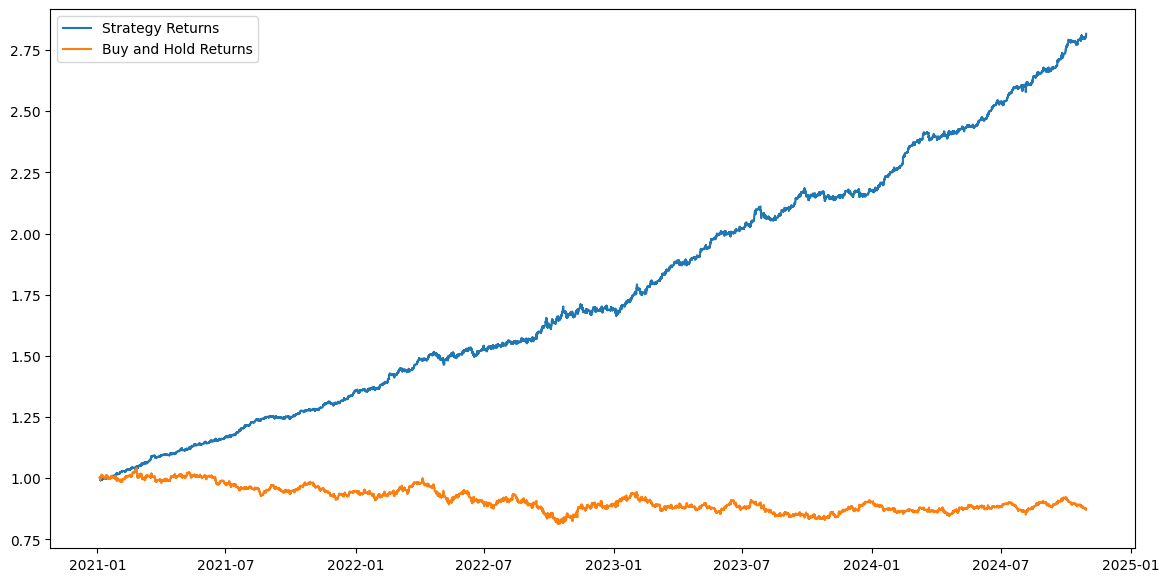

In [61]:
# strategy
df_filtered_2['pred'] = df_filtered_2['pred'].map({0: -1, 1: 1})
df_filtered_2['strategy'] = df_filtered_2['pred'] * df_filtered_2['s_returns']
df_filtered_2['cumulative_strategy_returns'] = df_filtered_2["strategy"].cumsum().apply(np.exp)

# plot
plt.figure(figsize=(14,7))
plt.plot(df_filtered_2['cumulative_strategy_returns'], label=f'Strategy Returns')
plt.plot(df_filtered_2['cumulative_buy_and_hold_returns'], label=f'Buy and Hold Returns')
plt.legend()
plt.show()

In [62]:
# Calculate wins and losses, treating losses as positive values
df_filtered_2['loss'] = np.where(df_filtered_2['strategy'] < 0, abs(df_filtered_2['strategy']), np.nan)
df_filtered_2['win'] = np.where(df_filtered_2['strategy'] > 0, df_filtered_2['strategy'], np.nan)

# Calculate the average win-to-loss ratio
win_loss_ratio = df_filtered_2['win'].mean() / df_filtered_2['loss'].mean()

# Handle cases where loss is zero or NaN
win_loss_ratio = np.where(np.isnan(win_loss_ratio) | (win_loss_ratio == 0), 1, win_loss_ratio)

# Calculate the Kelly Criterion using the improved formula
df_filtered_2['kelly'] = (df_filtered_2['prob'] - (1 - df_filtered_2['prob']) / win_loss_ratio)
win_loss_ratio

array(0.97753058)

In [63]:
# Actual returns associated with each trade
annualized_factor = 24960  # The number of 15-minute bars in a year
annualized_sreturn = np.mean(df_filtered_2['strategy']) * annualized_factor
print(f"Annualized Strategy Return: {annualized_sreturn:.2f}")

# Sharpe Ratio
risk_free_rate = 0  # Assuming risk-free rate is 0 for simplicity
mean_return = np.mean(df_filtered_2['strategy']) * annualized_factor
std_return = np.std(df_filtered_2['strategy']) * np.sqrt(annualized_factor)
sharpe_ratio = (mean_return - risk_free_rate) / std_return
print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f}")


# Maximum Drawdown
def max_drawdown(strategy_returns):
    cumulative = np.cumsum(strategy_returns)
    drawdown = cumulative - np.maximum.accumulate(cumulative)
    return np.min(drawdown)

max_dd = max_drawdown(df_filtered_2['strategy'])
print(f"Maximum Drawdown: {max_dd:.2f}")

Annualized Strategy Return: 1.16
Annualized Sharpe Ratio: 9.67
Maximum Drawdown: -0.04
